# OrcaFlex simulaties: added mass vs. no added mass

Deze notebook runt twee OrcaFlex `.dat` modellen:

1. **Met added mass**
2. **Zonder added mass**

Voor beide simulaties wordt dezelfde JONSWAP-golfconditie gebruikt en worden de extra dampingcoëfficiënten op nul gezet. Daarna worden **heave**, **pitch** en **roll** als overlay geplot en worden eenvoudige response metrics opgeslagen.

> Controleer vóór het runnen vooral de instellingen in cel 2: modelpaden, objectnamen, `Hs`, `Tp`, `gamma` en simulatieduur.

In [22]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import OrcFxAPI

In [23]:
# ============================================================
# 2. Instellingen
# ============================================================

# Modelbestanden
MODEL_CASES = {
    "added mass": Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_addedmass.dat"),
    "no added mass": Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_noaddedmass.dat"),
}

# Objectnamen in OrcaFlex, overgenomen uit je voorbeeldnotebook
vesselname = "floaters"
vesseltypename = "floatertype"

# Outputmap
output_dir = Path("orca_addedmass_comparison_jonswap")
output_dir.mkdir(parents=True, exist_ok=True)

# JONSWAP gemiddelde golfconditie
# AANNAME: ik heb de Hs/Tp uit je voorbeeldnotebook gebruikt als gemiddelde golven.
# Pas deze waarden aan als jouw gemiddelde condities anders zijn.
sea_state = {
    "Hs": 4.0,          # significant wave height [m]
    "Tp": 7.23,        # peak period [s]
    "gamma": 3.3,      # JONSWAP peak enhancement factor [-]
    "direction": 180.0,# wave direction [deg]
    "seed": 1,         # vaste seed zodat beide modellen exact dezelfde wave realisation krijgen
    "components": 200, # aantal wave components, indien beschikbaar in model/API
}

# Plot- en analyse-instellingen
plot_start_time = 0.0       # [s]
analysis_start_time = 0.0   # [s]
show_plots = True           # True = toon plots in notebook
save_plots = True           # True = sla plots op als .png
save_metrics = True         # True = sla metrics op als .csv

In [24]:
# ============================================================
# 3. Helper functies OrcaFlex
# ============================================================

def safe_name(text):
    """Maak een veilige bestandsnaam."""
    text = str(text).replace(".", "p")
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", text)


def try_set_data(obj, name, value, index=0, verbose=False):
    """
    Probeer OrcaFlex-data te zetten via attribute access of SetData.
    Dit maakt de notebook robuuster voor verschillende OrcaFlex-data-namen
    en voor scalar versus indexed/table data.
    """
    errors = []

    # 1) Attribute access: obj.DataName = value of obj.DataName[index] = value
    try:
        current = getattr(obj, name)
        try:
            current[index] = value
        except Exception:
            setattr(obj, name, value)
        return True
    except Exception as e:
        errors.append(f"attribute: {e}")

    # 2) SetData met index
    try:
        obj.SetData(name, index, value)
        return True
    except Exception as e:
        errors.append(f"SetData indexed: {e}")

    # 3) SetData zonder index
    try:
        obj.SetData(name, value)
        return True
    except Exception as e:
        errors.append(f"SetData scalar: {e}")

    if verbose:
        print(f"Kon {name} niet zetten naar {value!r}: {' | '.join(errors)}")
    return False


def set_first_available(obj, names, value, index=0, required=False, label=None):
    """Zet de eerste data name die werkt uit een lijst kandidaten."""
    for name in names:
        if try_set_data(obj, name, value, index=index):
            return name

    if required:
        shown = label or "/".join(names)
        raise RuntimeError(f"Kon verplichte OrcaFlex data niet zetten voor: {shown}. Kandidaten: {names}")
    return None


def select_first_wave_train(env):
    """Selecteer de eerste wave train, als dit model multi-wave-train data gebruikt."""
    # OrcaFlex gebruikt voor wave trains vaak 1-based selectie.
    try_set_data(env, "NumberOfWaveTrains", 1)
    try_set_data(env, "SelectedWaveTrainIndex", 1)


def set_jonswap_wave_condition(model, sea_state):
    """
    Zet een JONSWAP random wave conditie.

    De exacte data names kunnen per OrcaFlex-versie/model verschillen.
    Daarom worden zowel de WaveTrain*-namen als de oudere Wave*-namen geprobeerd.
    """
    env = model.environment
    select_first_wave_train(env)

    Hs = float(sea_state["Hs"])
    Tp = float(sea_state["Tp"])
    gamma = float(sea_state.get("gamma", 3.3))
    direction = float(sea_state.get("direction", 180.0))
    seed = int(sea_state.get("seed", 1))
    components = int(sea_state.get("components", 200))

    applied = {}

    applied["wave_type"] = set_first_available(
        env,
        ["WaveTrainType", "WaveType"],
        "JONSWAP",
        required=True,
        label="wave type / JONSWAP",
    )

    applied["Hs"] = set_first_available(
        env,
        ["WaveTrainHs", "WaveHs", "WaveHeight"],
        Hs,
        required=True,
        label="JONSWAP Hs",
    )

    applied["Tp"] = set_first_available(
        env,
        ["WaveTrainTp", "WaveTp", "WavePeriod"],
        Tp,
        required=True,
        label="JONSWAP Tp",
    )

    applied["gamma"] = set_first_available(
        env,
        ["WaveTrainGamma", "WaveGamma", "JONSWAPGamma"],
        gamma,
        required=False,
        label="JONSWAP gamma",
    )

    applied["direction"] = set_first_available(
        env,
        ["WaveTrainDirection", "WaveDirection"],
        direction,
        required=False,
        label="wave direction",
    )

    # Origin en time origin
    set_first_available(env, ["WaveTrainOriginX", "WaveOriginX"], 0.0)
    set_first_available(env, ["WaveTrainOriginY", "WaveOriginY"], 0.0)
    set_first_available(env, ["WaveTrainTimeOrigin", "WaveTimeOrigin"], 0.0)

    # Reproduceerbare random wave realisation
    set_first_available(env, ["WaveTrainSeed", "WaveSeed"], seed)
    set_first_available(env, ["WaveTrainNumberOfComponents", "WaveNumberOfComponents"], components)

    return applied


def reset_initial_position(vessel):
    """Zet initiële offsets terug naar nul."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0


def set_no_extra_damping(vesseltype):
    """Zet alle extra heave/pitch/roll damping op nul."""
    # Mapping: heave = Z, roll = Rx / Rotation 1, pitch = Ry / Rotation 2.
    damping_items = [
        "OtherDampingLinearCoeffZ",
        "OtherDampingQuadraticCoeffZ",
        "OtherDampingLinearCoeffRy",
        "OtherDampingQuadraticCoeffRy",
        "OtherDampingLinearCoeffRx",
        "OtherDampingQuadraticCoeffRx",
    ]

    for item in damping_items:
        ok = try_set_data(vesseltype, item, 0.0)
        if not ok:
            print(f"Waarschuwing: kon {item} niet op nul zetten.")


def run_orcaflex_model(model_path, sea_state):
    """Laadt model, zet JONSWAP en damping=0, runt simulatie en leest responses uit."""
    model = OrcFxAPI.Model(str(model_path))

    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    reset_initial_position(vessel)
    applied_wave_data = set_jonswap_wave_condition(model, sea_state)
    set_no_extra_damping(vesseltype)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    responses = {
        "heave": np.asarray(vessel.TimeHistory("Z"), dtype=float),
        "pitch": np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float),
        "roll":  np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float),
    }
    return t, responses, applied_wave_data


def response_metrics(t, y):
    """Bereken eenvoudige response metrics na analysis_start_time."""
    t = np.asarray(t)
    y = np.asarray(y)
    mask = t >= analysis_start_time
    z = y[mask]

    if len(z) == 0:
        return {"mean": np.nan, "std": np.nan, "rms": np.nan, "max_abs": np.nan, "ptp": np.nan}

    return {
        "mean": float(np.mean(z)),
        "std": float(np.std(z)),
        "rms": float(np.sqrt(np.mean(z**2))),
        "max_abs": float(np.max(np.abs(z))),
        "ptp": float(np.ptp(z)),
    }

In [25]:
# ============================================================
# 4. Simulaties runnen
# ============================================================

all_time_histories = {}
metrics_rows = []
applied_wave_settings = {}

Hs = float(sea_state["Hs"])
Tp = float(sea_state["Tp"])
gamma = float(sea_state.get("gamma", 3.3))
direction = float(sea_state.get("direction", 180.0))
sea_key = f"JONSWAP_Hs{Hs:g}_Tp{Tp:g}_gamma{gamma:g}_Dir{direction:g}"

print("=" * 90)
print(f"Sea state: JONSWAP, Hs={Hs:g} m, Tp={Tp:g} s, gamma={gamma:g}, direction={direction:g} deg")
print("Extra damping: 0 voor heave, pitch en roll")
print("=" * 90)

for case_name, model_path in MODEL_CASES.items():
    print(f"Running case: {case_name}")
    print(f"Model: {model_path}")

    try:
        t, responses, applied = run_orcaflex_model(model_path, sea_state)
        applied_wave_settings[case_name] = applied
        all_time_histories[case_name] = {"t": t, **responses}

        for response_name, y in responses.items():
            m = response_metrics(t, y)
            metrics_rows.append({
                "sea_key": sea_key,
                "Hs_m": Hs,
                "Tp_s": Tp,
                "gamma": gamma,
                "direction_deg": direction,
                "wave_type": "JONSWAP",
                "case": case_name,
                "model_path": str(model_path),
                "response": response_name,
                "status": "ok",
                **m,
            })

        print(f"OK: {case_name}")

    except Exception as e:
        print(f"FAILED: {case_name}: {e}")
        for response_name in ["heave", "pitch", "roll"]:
            metrics_rows.append({
                "sea_key": sea_key,
                "Hs_m": Hs,
                "Tp_s": Tp,
                "gamma": gamma,
                "direction_deg": direction,
                "wave_type": "JONSWAP",
                "case": case_name,
                "model_path": str(model_path),
                "response": response_name,
                "status": "failed",
                "error": str(e),
                "mean": np.nan,
                "std": np.nan,
                "rms": np.nan,
                "max_abs": np.nan,
                "ptp": np.nan,
            })

metrics_df = pd.DataFrame(metrics_rows)
print("\nGebruikte OrcaFlex wave data names per case:")
for case_name, applied in applied_wave_settings.items():
    print(case_name, applied)

metrics_df

Sea state: JONSWAP, Hs=4 m, Tp=7.23 s, gamma=3.3, direction=180 deg
Extra damping: 0 voor heave, pitch en roll
Running case: added mass
Model: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_addedmass.dat
OK: added mass
Running case: no added mass
Model: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_noaddedmass.dat
OK: no added mass

Gebruikte OrcaFlex wave data names per case:
added mass {'wave_type': 'WaveTrainType', 'Hs': 'WaveTrainHs', 'Tp': 'WaveTrainTp', 'gamma': 'WaveTrainGamma', 'direction': 'WaveTrainDirection'}
no added mass {'wave_type': 'WaveTrainType', 'Hs': 'WaveTrainHs', 'Tp': 'WaveTrainTp', 'gamma': 'WaveTrainGamma', 'direction': 'WaveTrainDirection'}


,sea_key,Hs_m,Tp_s,gamma,direction_deg,wave_type,case,model_path,response,status,mean,std,rms,max_abs,ptp
0,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,heave,ok,-1.316276e-01,1.385738e+00,1.391975e+00,3.932843e+00,7.767081e+00
1,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,pitch,ok,2.172060e-01,2.128145e+01,2.128256e+01,4.966215e+01,9.872838e+01
2,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,roll,ok,2.547083e-14,2.911976e-13,2.923094e-13,1.192794e-12,2.323665e-12
3,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,no added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,heave,ok,-2.105729e-02,1.677616e+00,1.677748e+00,4.829986e+00,9.263717e+00
4,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,no added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,pitch,ok,3.750180e-01,2.299383e+01,2.299689e+01,5.155562e+01,1.016913e+02
5,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,no added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,roll,ok,-1.184097e-15,5.145350e-13,5.145364e-13,2.548115e-12,4.961624e-12


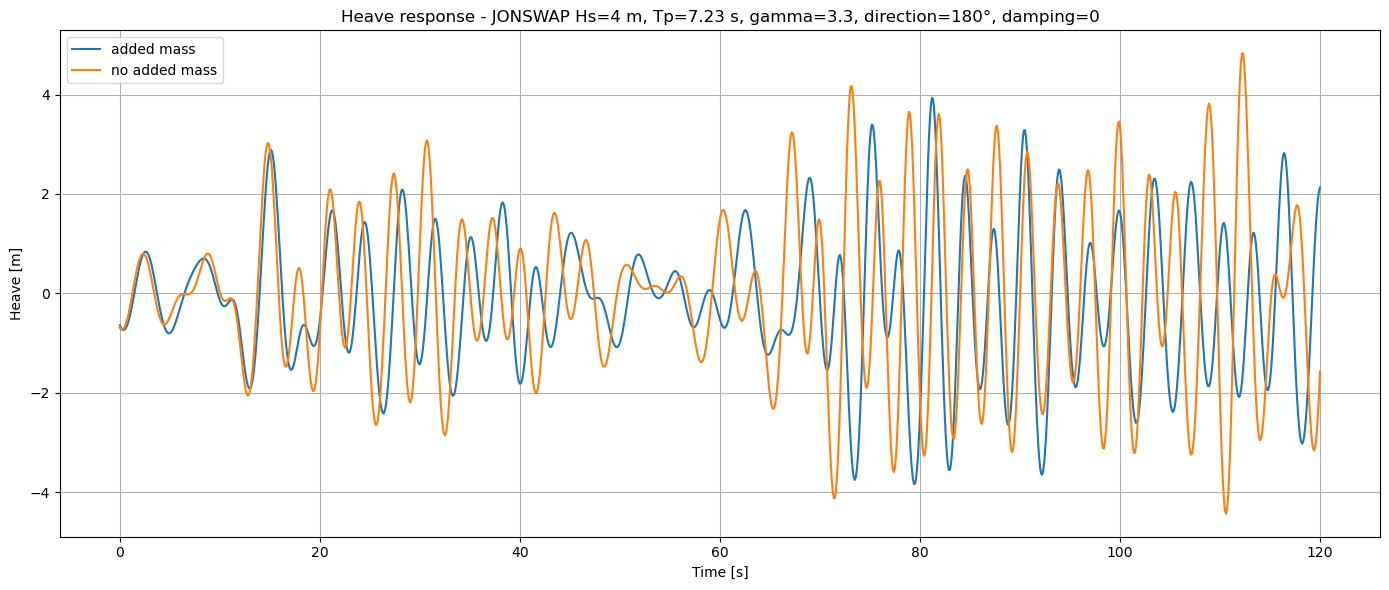

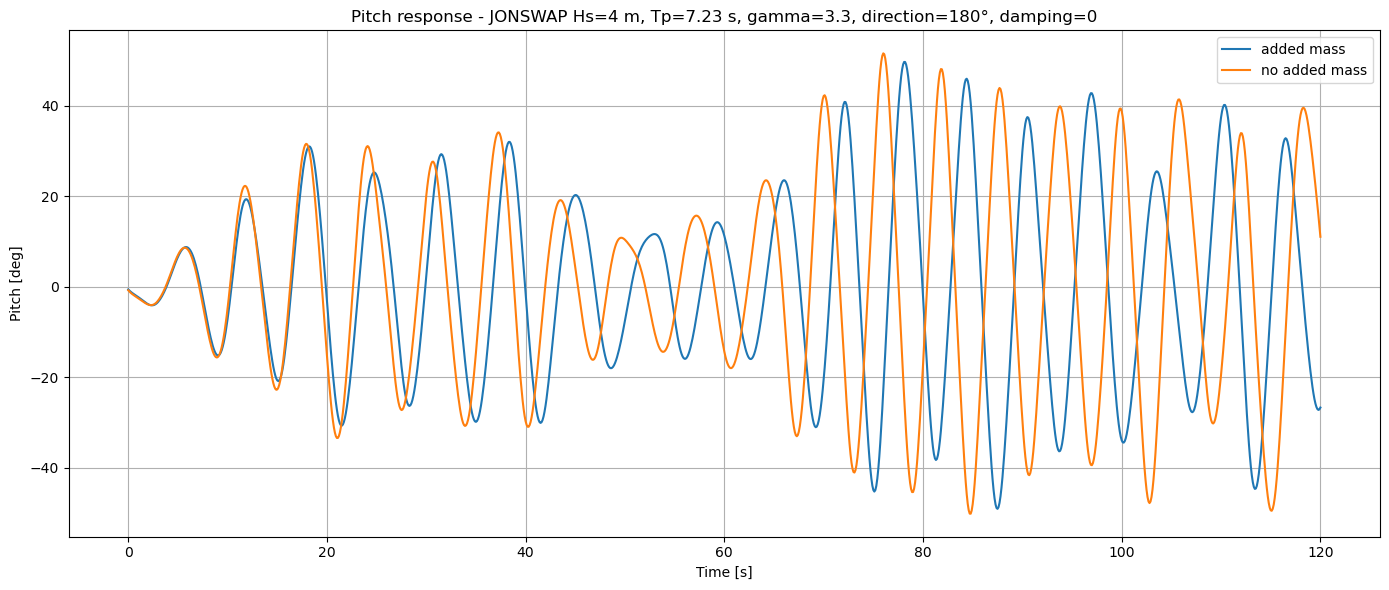

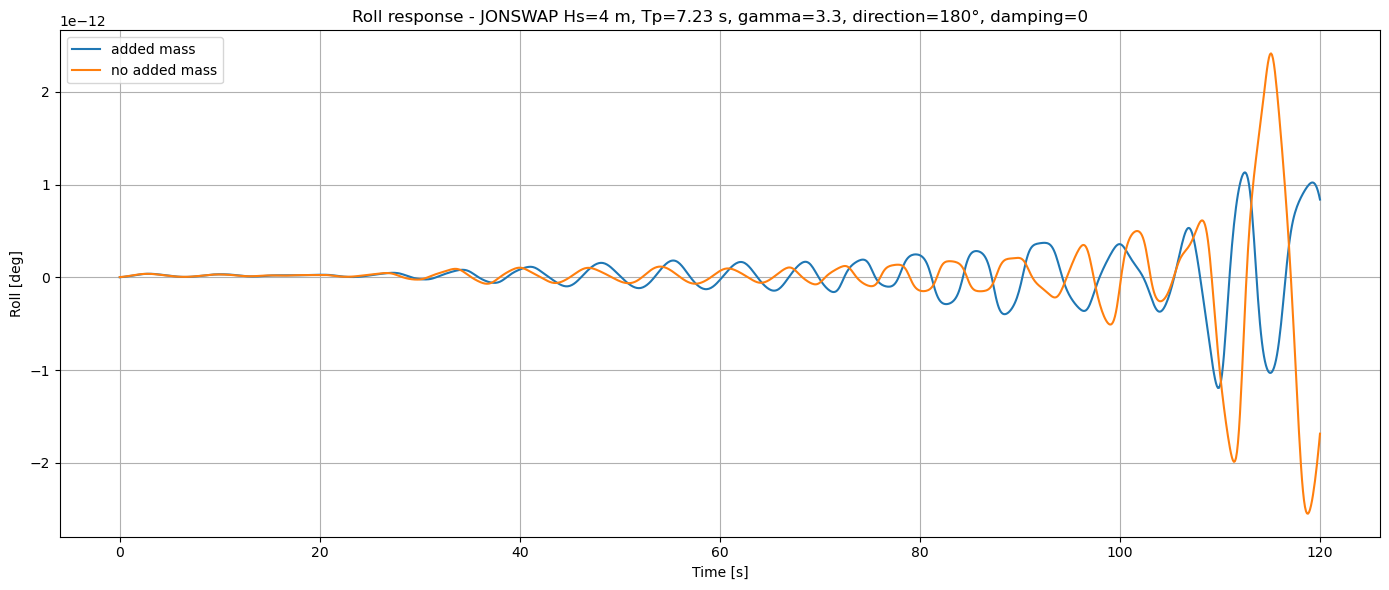

Opgeslagen figuren:
orca_addedmass_comparison_jonswap\JONSWAP_Hs4_Tp7p23_gamma3p3_Dir180_heave_addedmass_vs_noaddedmass.png
orca_addedmass_comparison_jonswap\JONSWAP_Hs4_Tp7p23_gamma3p3_Dir180_pitch_addedmass_vs_noaddedmass.png
orca_addedmass_comparison_jonswap\JONSWAP_Hs4_Tp7p23_gamma3p3_Dir180_roll_addedmass_vs_noaddedmass.png


In [26]:
# ============================================================
# 5. Plots: added mass vs. no added mass
# ============================================================

response_labels = {
    "heave": ("Heave", "Heave [m]"),
    "pitch": ("Pitch", "Pitch [deg]"),
    "roll":  ("Roll", "Roll [deg]"),
}

saved_figures = []

for response_name, (response_title, ylabel) in response_labels.items():
    fig, ax = plt.subplots(figsize=(14, 6))

    for case_name, data in all_time_histories.items():
        t = data["t"]
        y = data[response_name]
        mask = t >= plot_start_time
        ax.plot(t[mask], y[mask], linewidth=1.5, label=case_name)

    ax.set_xlabel("Time [s]")
    ax.set_ylabel(ylabel)
    ax.set_title(
        f"{response_title} response - JONSWAP Hs={Hs:g} m, Tp={Tp:g} s, "
        f"gamma={gamma:g}, direction={direction:g}°, damping=0"
    )
    ax.grid(True)
    ax.legend()
    fig.tight_layout()

    if save_plots:
        filename = output_dir / f"{safe_name(sea_key)}_{response_name}_addedmass_vs_noaddedmass.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        saved_figures.append(filename)

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

print("Opgeslagen figuren:")
for f in saved_figures:
    print(f)

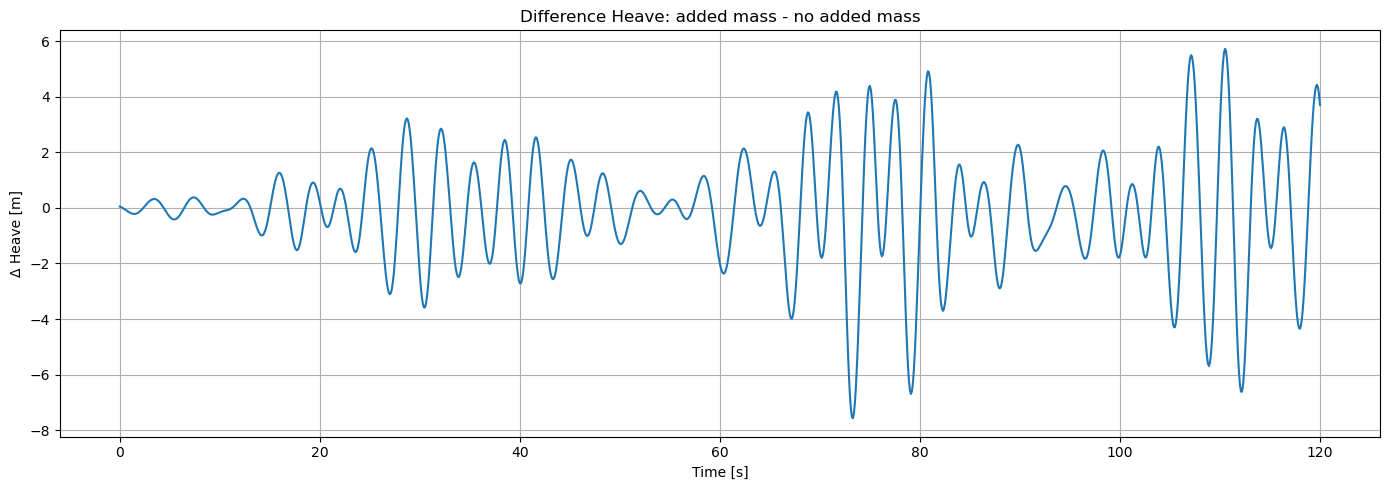

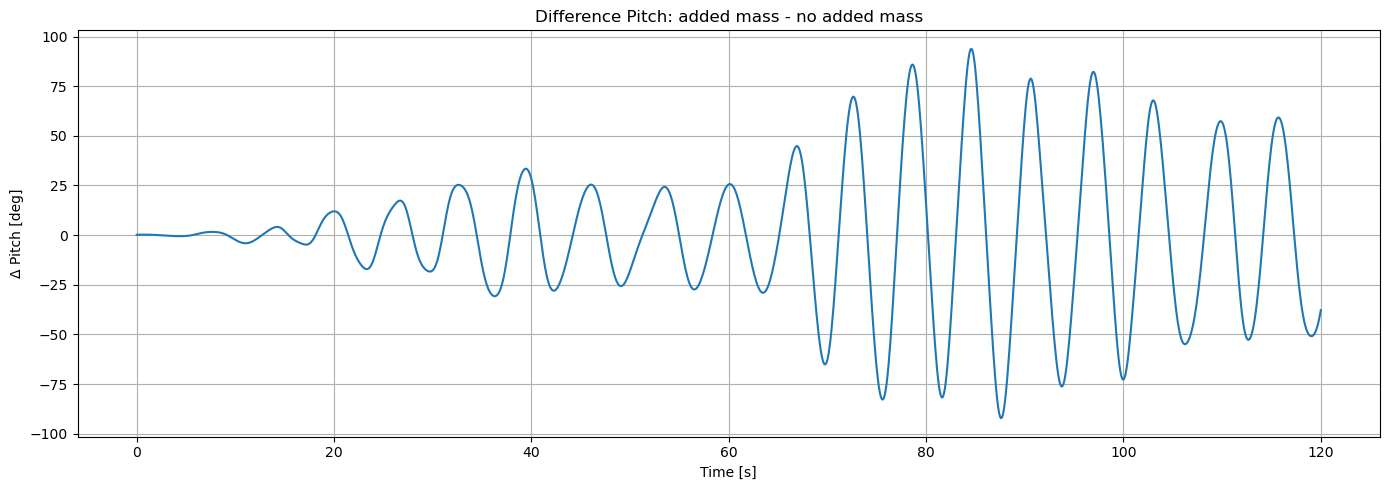

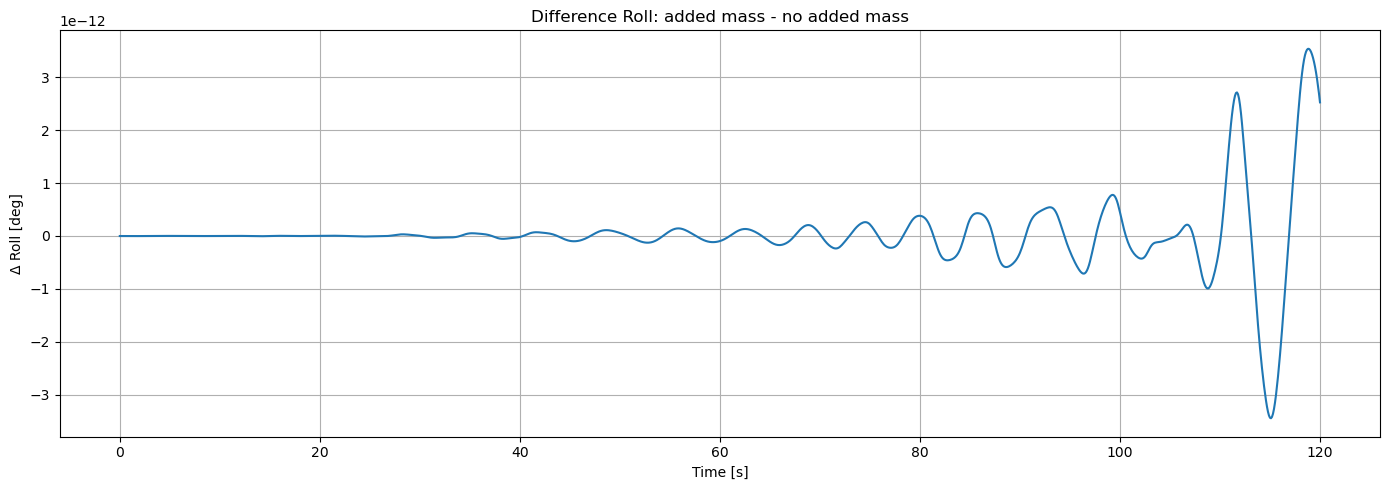

Opgeslagen verschilfiguren:
orca_addedmass_comparison_jonswap\JONSWAP_Hs4_Tp7p23_gamma3p3_Dir180_heave_difference_added_minus_noadded.png
orca_addedmass_comparison_jonswap\JONSWAP_Hs4_Tp7p23_gamma3p3_Dir180_pitch_difference_added_minus_noadded.png
orca_addedmass_comparison_jonswap\JONSWAP_Hs4_Tp7p23_gamma3p3_Dir180_roll_difference_added_minus_noadded.png


In [27]:
# ============================================================
# 6. Verschilplots: added mass minus no added mass
# ============================================================

if "added mass" in all_time_histories and "no added mass" in all_time_histories:
    saved_diff_figures = []

    t_added = all_time_histories["added mass"]["t"]
    t_no = all_time_histories["no added mass"]["t"]

    # Gebruik interpolatie voor het geval de tijdvectors net anders zijn.
    for response_name, (response_title, ylabel) in response_labels.items():
        y_added = all_time_histories["added mass"][response_name]
        y_no = all_time_histories["no added mass"][response_name]
        y_no_interp = np.interp(t_added, t_no, y_no)
        diff = y_added - y_no_interp
        mask = t_added >= plot_start_time

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(t_added[mask], diff[mask], linewidth=1.5)
        ax.set_xlabel("Time [s]")
        ax.set_ylabel(f"Δ {ylabel}")
        ax.set_title(f"Difference {response_title}: added mass - no added mass")
        ax.grid(True)
        fig.tight_layout()

        if save_plots:
            filename = output_dir / f"{safe_name(sea_key)}_{response_name}_difference_added_minus_noadded.png"
            fig.savefig(filename, dpi=300, bbox_inches="tight")
            saved_diff_figures.append(filename)

        if show_plots:
            plt.show()
        else:
            plt.close(fig)

    print("Opgeslagen verschilfiguren:")
    for f in saved_diff_figures:
        print(f)
else:
    print("Verschilplots overgeslagen: niet beide cases zijn succesvol gerund.")

In [28]:
# ============================================================
# 7. Metrics opslaan
# ============================================================

if save_metrics:
    metrics_path = output_dir / "response_metrics_addedmass_vs_noaddedmass_jonswap.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print(f"Metrics opgeslagen naar: {metrics_path}")

metrics_df

Metrics opgeslagen naar: orca_addedmass_comparison_jonswap\response_metrics_addedmass_vs_noaddedmass_jonswap.csv


,sea_key,Hs_m,Tp_s,gamma,direction_deg,wave_type,case,model_path,response,status,mean,std,rms,max_abs,ptp
0,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,heave,ok,-1.316276e-01,1.385738e+00,1.391975e+00,3.932843e+00,7.767081e+00
1,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,pitch,ok,2.172060e-01,2.128145e+01,2.128256e+01,4.966215e+01,9.872838e+01
2,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,roll,ok,2.547083e-14,2.911976e-13,2.923094e-13,1.192794e-12,2.323665e-12
3,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,no added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,heave,ok,-2.105729e-02,1.677616e+00,1.677748e+00,4.829986e+00,9.263717e+00
4,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,no added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,pitch,ok,3.750180e-01,2.299383e+01,2.299689e+01,5.155562e+01,1.016913e+02
5,JONSWAP_Hs4_Tp7.23_gamma3.3_Dir180,4.0,7.23,3.3,180.0,JONSWAP,no added mass,C:\Users\verav\Desktop\Studie\Afstuderen\PHASE...,roll,ok,-1.184097e-15,5.145350e-13,5.145364e-13,2.548115e-12,4.961624e-12


## Notities

- De notebook gebruikt dezelfde runstructuur als je voorbeeld: model laden, golfconditie zetten, damping zetten, `RunSimulation()`, en daarna tijdseries uitlezen.
- Voor JONSWAP gebruikt de notebook een vaste seed zodat beide cases dezelfde random wave realisation krijgen.
- De helperfunctie probeert meerdere OrcaFlex data names, omdat OrcaFlex-modellen/versies kunnen verschillen tussen `WaveTrain*` en `Wave*` data fields.
- Als een golfparameter niet gezet kan worden, print de notebook welke stap faalt. In dat geval kun je in OrcaFlex met **F7** op het relevante data field de exacte data name controleren.